Problem 1 : Régression Linéaire Simple — Budget Marketing vs Trafic Site Web

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [2]:
budget_marketing_visiteurs = pd.read_csv('../dataset/budget_marketing_visiteurs/budget_marketing_visiteurs.csv')
print(budget_marketing_visiteurs)

   Budget Marketing (k AED)  Visiteurs Uniques
0                         5               1200
1                         8               1850
2                        12               2600
3                        15               3100
4                        20               4300
5                        25               5000


shape data before split:  (6, 1) (6,)
shape data after split: (4, 1) (4,)
[1200 1850]
model Evaluation: 
score_1: 0.9768932570009043
score_2: 0.9768932570009043
score_3: 38.775510204081684
RESULTS: 
Coef/slope: 190.81632653061223
Intercept:   315.30612244897975
Prediction: [1269.3877551  1841.83673469]
prediction_30k [6039.79591837]
Visitors = 190.82 * Budget + 315.31
Actual: 1200, Predicted: 1269.387755102041
Actual: 1850, Predicted: 1841.8367346938776


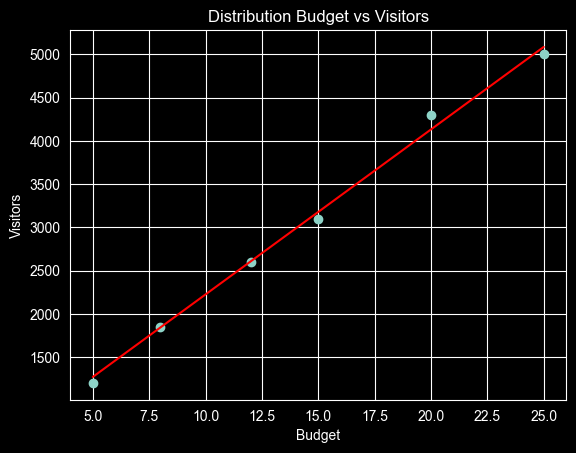

"\nLes principales améliorations concernent la visualisation (tracer les données réelles et la droite de régression) et l'évaluation du modèle (R², MAE, comparaison entre valeurs réelles et prédites).\n"

In [3]:
X = np.array(budget_marketing_visiteurs.iloc[:,0]).reshape(-1,1) # budget
y = np.array(budget_marketing_visiteurs.iloc[:,1]) # visitors

#shape of data before split 
print(f"shape data before split: ", X.shape, y.shape) 

# split data into set train and set test
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

#shape of data before split 
print(f"shape data after split:", X_train.shape, y_train.shape)

# model selection
model  = LinearRegression()
# train model
model.fit(X_train, y_train)
#model params
coef = model.coef_[0]
intercept = model.intercept_
#predictions
prediction = model.predict(X_test)
print(y_test) #<-  optional -> just to verify if my prediction is okay
# prediction_30k  
prediction_30k = model.predict([[30]])

# model Evaluation

print(f"{'model Evaluation: '}")
score_1 = model.score(X_test, y_test)
print(f"score_1: {score_1}")
from sklearn.metrics import mean_absolute_error ,r2_score
score_2 = r2_score(y_test,prediction)
print(f"score_2: {score_2}")
score_3 = mean_absolute_error(y_test,prediction)
print(f"score_3: {score_3}")


print(f"{'RESULTS: '}")
print(f"Coef/slope: {coef}\n" 
      f"Intercept:   {intercept}\n"
      f"Prediction: {prediction}\n"
      f"prediction_30k {prediction_30k}")


# Equation
print(f"Visitors = {coef:.2f} * Budget + {intercept:.2f}" )

# compare y_test vs prediction

for actual, predicted in zip(y_test,prediction):
    print(f"Actual: {actual}, Predicted: {predicted}")

# interpretation interprétation
'''

1- sujet de la slope:

The slope is 190.
This means that for any additional 1000 thaousand add in marketing, the website gains approximativly 190 visitors

ou

La pente (190) signifie qu'en moyenne, chaque augmentation de 1 kAED (1 000 AED) du budget marketing est associée à environ 191 visiteurs uniques supplémentaires sur le site web.


2- sujet de l'extrapolation

L'extrapolation est risquée parce que le modèle fait une prédiction en dehors de la plage de données observées (au-delà de 25 kAED). Rien ne garantit que la relation restera linéaire pour des budgets plus élevés. Dans la réalité, les visiteurs peuvent augmenter plus lentement, atteindre un plateau ou être influencés par d'autres facteurs.
'''
plt.scatter(X, y) # True observations
plt.plot(X, model.predict(X), color='red') # line of prediction on X
plt.xlabel("Budget")
plt.ylabel("Visitors")
plt.title("Distribution Budget vs Visitors")
plt.show()



# Les principales améliorations
'''
Les principales améliorations concernent la visualisation (tracer les données réelles et la droite de régression) et l'évaluation du modèle (R², MAE, comparaison entre valeurs réelles et prédites).
'''

# Questions de compréhension :
#La pente y = ax+b
1- La pente obtenue "Coef/slope: [190.81632653]" reprensente la variation moyenne de la variable (Δ) independante lorsque la variable (Δ) dependante augmente de d'une unite.  on fait (Δy=a×Δx).

Dans mon cas je peux dire que, La pente (190.82) signifie qu'en moyenne, chaque augmentation de budget de 1k (1000AED) du budget marketing, est associer a environ 191 visiteurs visiteurs uniques sur le site web.

2- 
    - Avec 6 points de données, et dans X_test avec test_size=0.2, je vais avoir 2 points dans mon cas bien que 20% de 6 points de donnees me donne : 1.2.
    - Non avec juste 2 points de donnees ce n'est pas suiffisant pour evaluer le modele, mais aussi cela depend de la maniere dont les donnees sont decoupees.
3- L'extrapolation est risquer en Regression lineaire parceque une decision importante peut etre prise sur l'influence d'une seule variable alors que normalement on en a souvent plusieurs

4- Si l'intercept est negatif, pour un budget de 0, la prediction serait negatiave et ce n'est pas realiste.
5- le trafic peut augmenter avec lan regression lineaire mais pas de facon indefinie car le trafic depend aussi d'autres features independante. 
Et cela montre la limite de la regression lineaire.

## Conceptual Questions

**1. The slope (y = ax + b)**

The slope **(190.81632653)** represents the average change in the dependent variable when the independent variable increases by one unit.

We can write it as:

**Δy = a × Δx**

In this example, the slope (190.82) means that, on average, for every additional **1k AED (1,000 AED)** spent on marketing, the website gets about **191 more unique visitors**.

---

**2. With 6 data points and `test_size=0.2`, how many points will be in `X_test`? Is it enough to evaluate the model?**

* With 6 data points and `test_size=0.2`, I got **2 data points** in my test set, even though 20% of 6 is **1.2**.
* I don't think 2 data points are enough to properly evaluate the model. Also, it depends on how the data is split.

---

**3. Why is extrapolation risky in linear regression?**

I think extrapolation is risky because an important decision could be made based on the influence of only one variable, while in real life there are usually many variables that affect the result.

---

**4. What if the intercept is negative?**

If the intercept is negative, then with a marketing budget of **0 AED**, the prediction would also be negative. This is not realistic because the number of visitors cannot be negative.

---

**5. Can website traffic continue to increase linearly forever?**

No. Website traffic cannot continue to increase linearly forever because it also depends on other independent features. This shows one of the limitations of a linear regression model.

I'm still learning, so I'd appreciate any feedback or corrections. Thanks!


Problem 2 : Régression Linéaire Simple — Budget Marketing vs Trafic Site Web

In [3]:
#100DaysOfCode

tu as dis que Cette distance entre le point réel et la droite est appelée le résidu (residual).
Plus les résidus sont grands, plus les données sont bruitées.